In [7]:
import sys
print(sys.executable)


c:\Users\Xandão\Desktop\Jaciara\Jaciara_Dados\projeto_churn\venv\Scripts\python.exe


In [8]:
# ==========================
# IMPORTAÇÃO DE BIBLIOTECAS
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


In [9]:
df = pd.read_csv("../data/telecom_customer_churn.csv")

df.head()


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [10]:
df.shape

(7043, 38)

In [11]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   str    
 12  Pho

In [12]:
df["Customer Status"].value_counts()


Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

In [13]:
df["Customer Status"].value_counts(normalize=True)*100

Customer Status
Stayed     67.016896
Churned    26.536987
Joined      6.446117
Name: proportion, dtype: float64

In [14]:
df["Churn_Binary"] = df["Customer Status"].map({
    "Stayed": 0,
    "Joined": 0,
    "Churned": 1
})


In [15]:
df["Churn_Binary"].isna().sum()


np.int64(0)

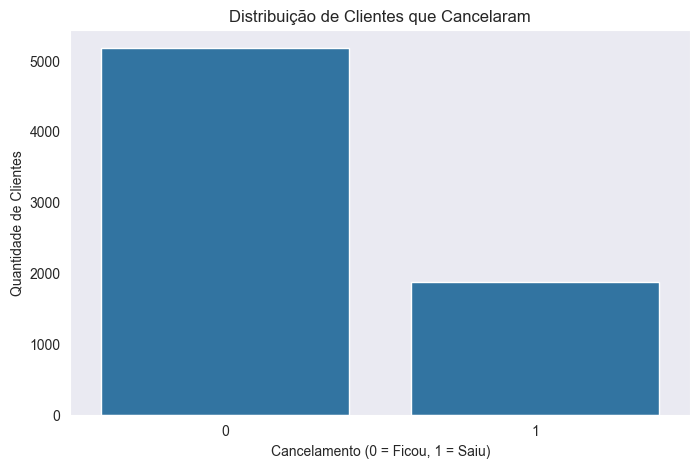

A porcentagem de clientes que cancelaram é 26.54%


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo dos gráficos
sns.set_style("dark")
plt.rcParams["figure.figsize"] = (8,5)

# Contagem de clientes que cancelaram (1) e que ficaram (0)
sns.countplot(x="Churn_Binary", data=df)
plt.title("Distribuição de Clientes que Cancelaram")  # Título do gráfico
plt.xlabel("Cancelamento (0 = Ficou, 1 = Saiu)")      # Nome do eixo X
plt.ylabel("Quantidade de Clientes")           # Nome do eixo Y
plt.show()                                     # Exibe o gráfico

# Percentual de clientes que churnaram
percent_churn = df["Churn_Binary"].mean() * 100
print(f"A porcentagem de clientes que cancelaram é {percent_churn:.2f}%")


In [17]:
# Selecionar todas as colunas categóricas (texto)
categorical_cols = df.select_dtypes(include='object').columns
print("Colunas categóricas do dataset:", categorical_cols)

# Para cada coluna categórica, ver a distribuição das categorias
for col in categorical_cols:
    print(f"\nDistribuição da coluna '{col}':")
    print(df[col].value_counts())
    print("-"*50)


Colunas categóricas do dataset: Index(['Customer ID', 'Gender', 'Married', 'City', 'Offer', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Internet Type',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='str')

Distribuição da coluna 'Customer ID':
Customer ID
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
0013-EXCHZ    1
             ..
9987-LUTYD    1
9992-RRAMN    1
9992-UJOEL    1
9993-LHIEB    1
9995-HOTOH    1
Name: count, Length: 7043, dtype: int64
--------------------------------------------------

Distribuição da coluna 'Gender':
Gender
Male      3555
Female    3488
Name: count, dtype: int64
--------------------------------------------------

Distribuição da coluna 'Married':
Married
No     36

C:\Users\Xandão\AppData\Local\Temp\ipykernel_13128\2798210377.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


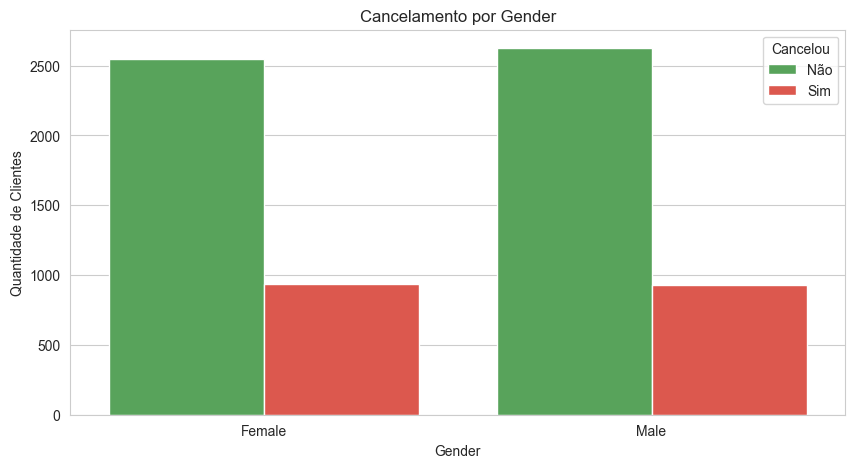

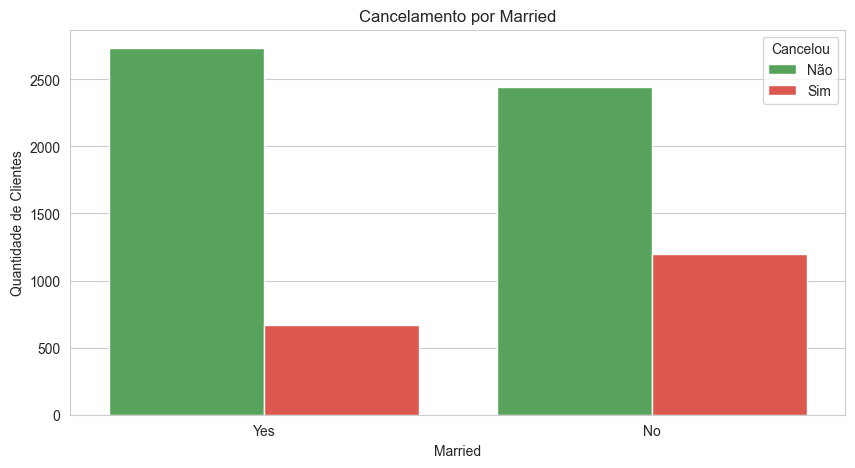

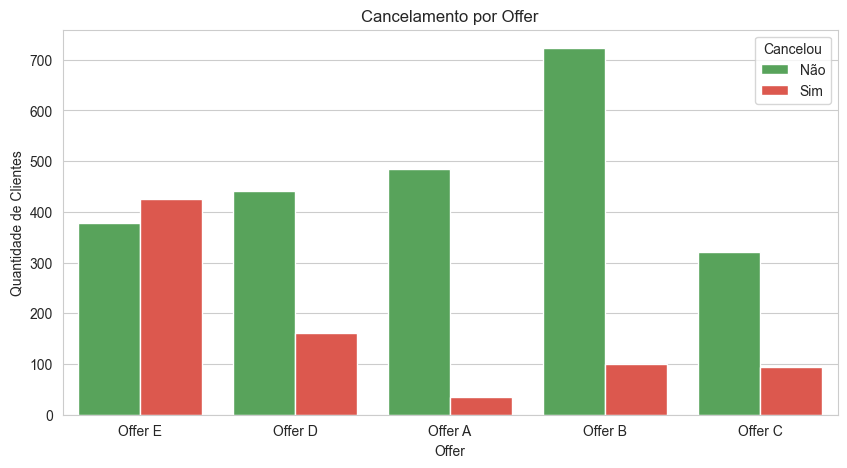

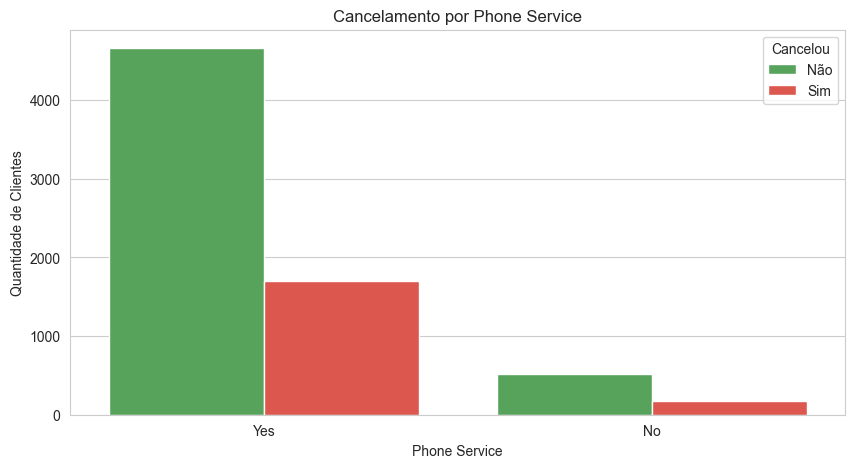

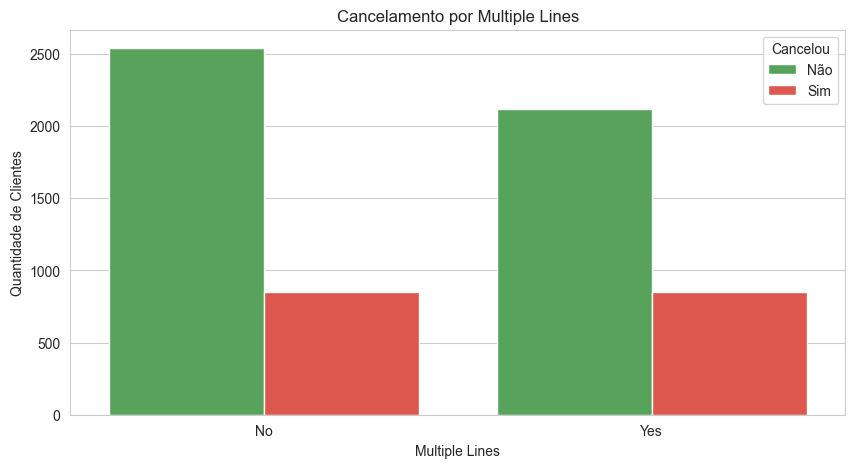

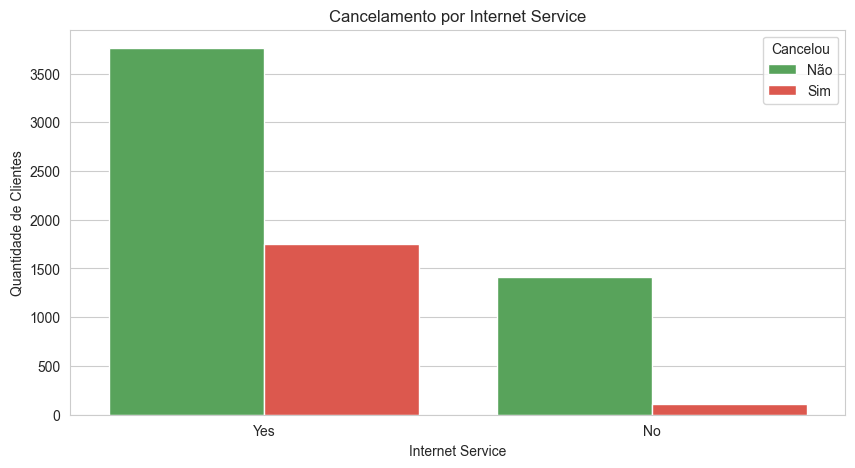

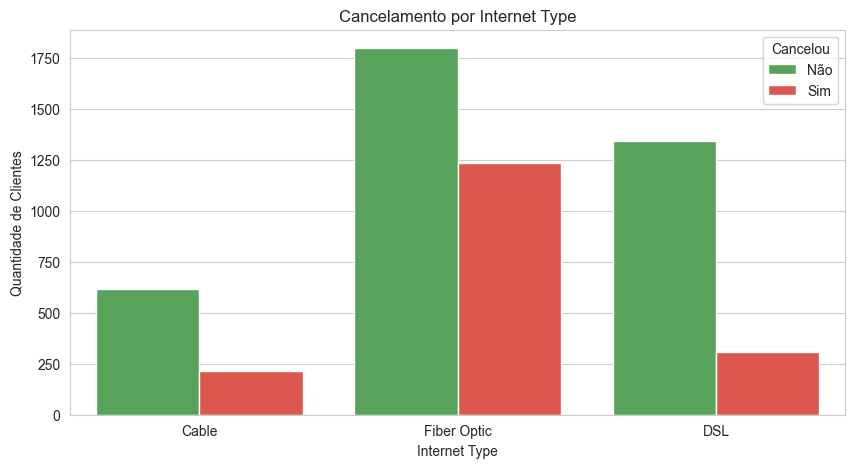

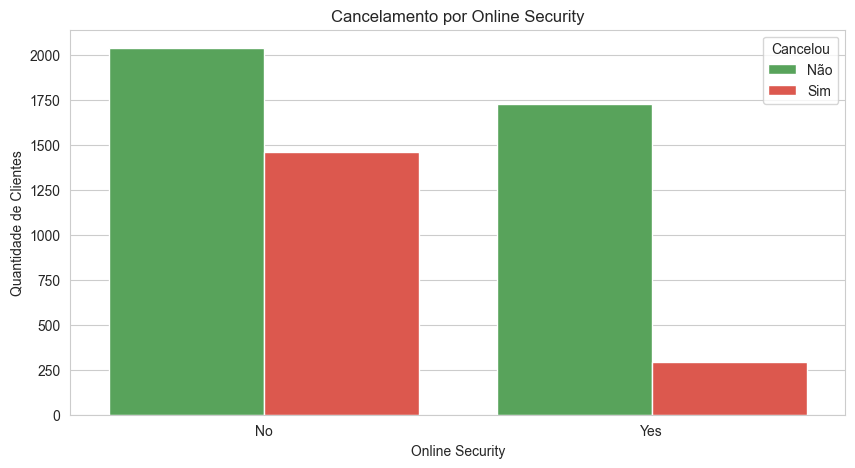

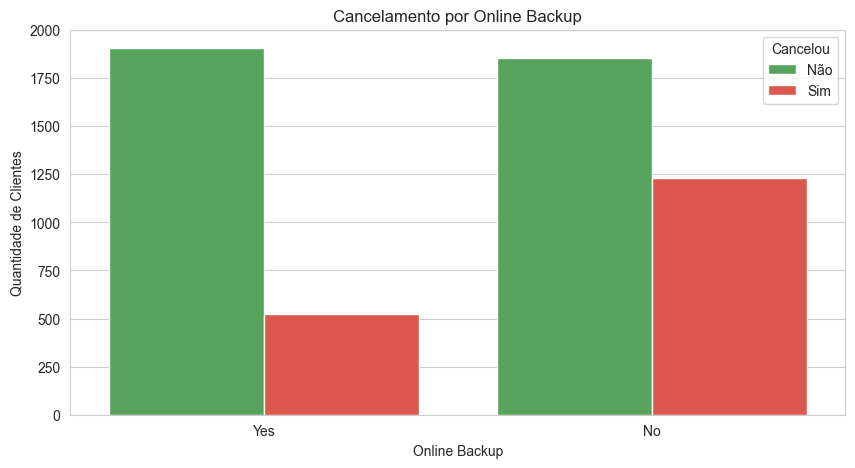

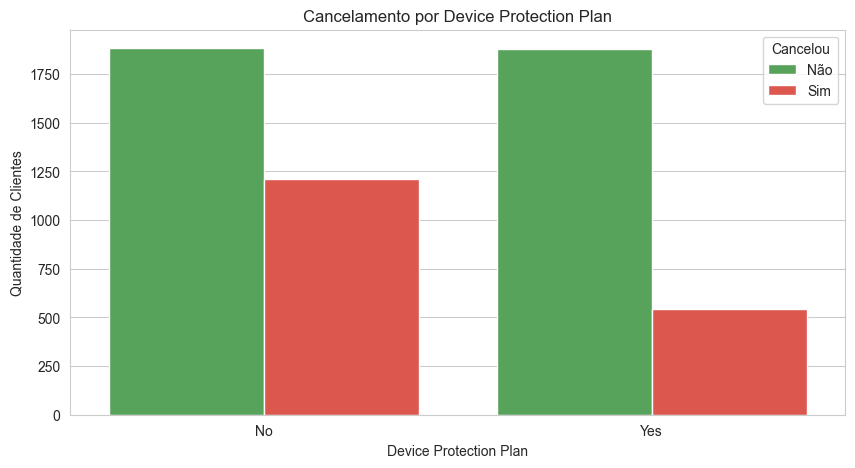

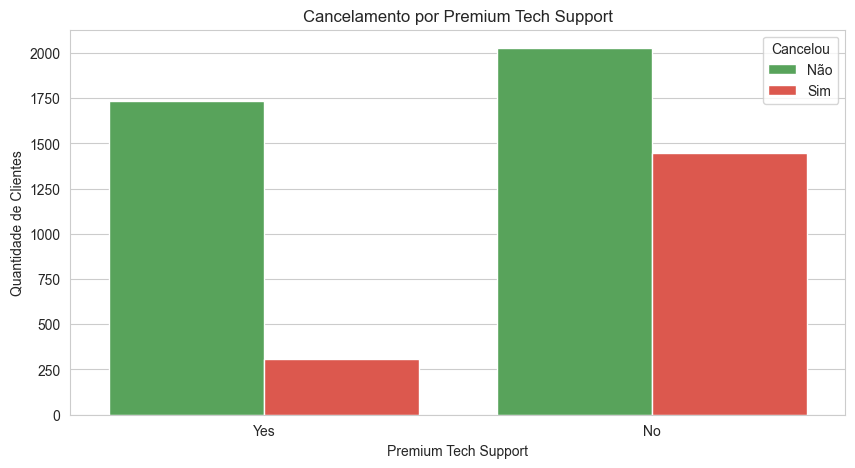

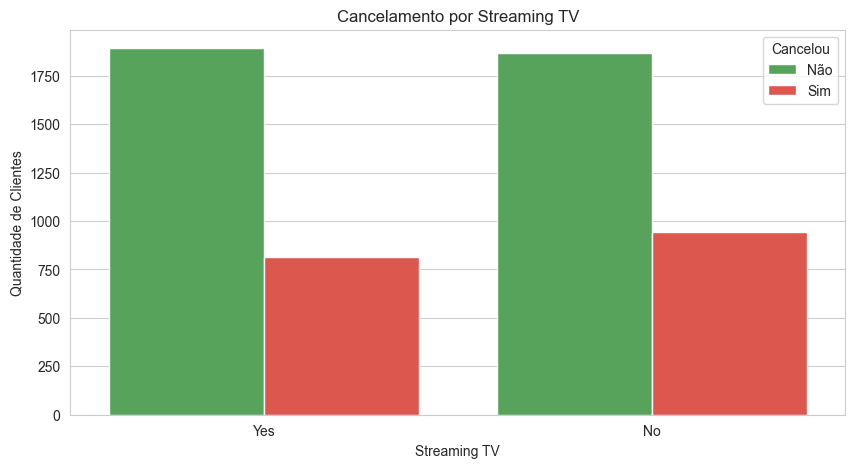

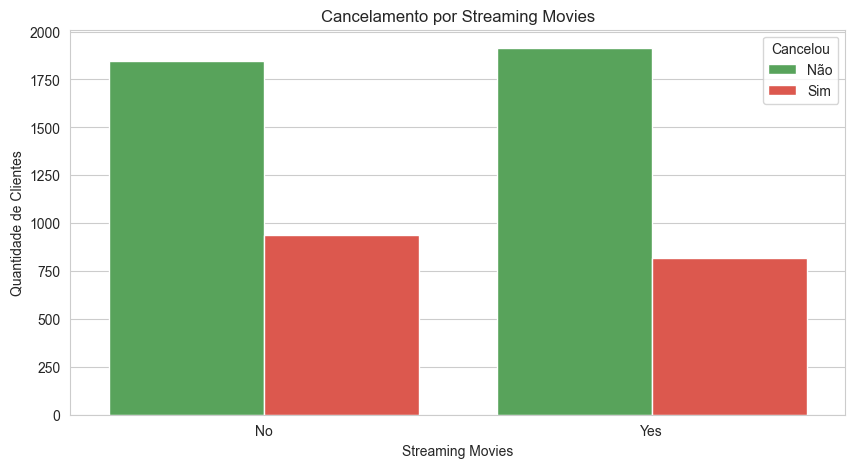

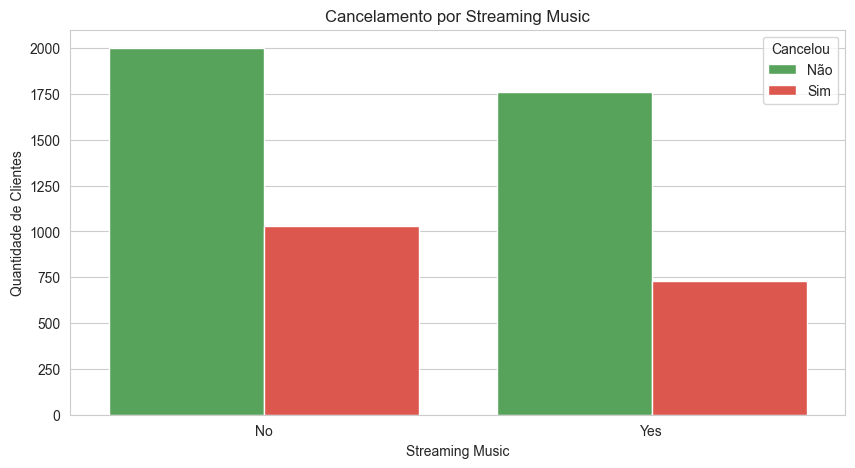

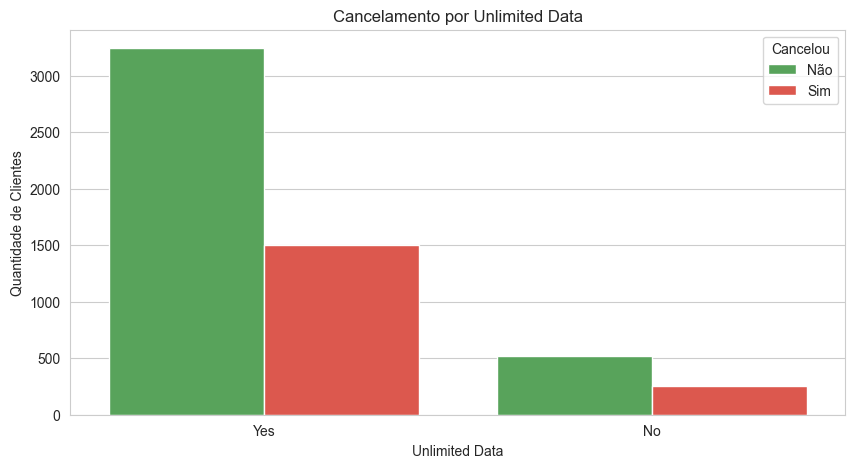

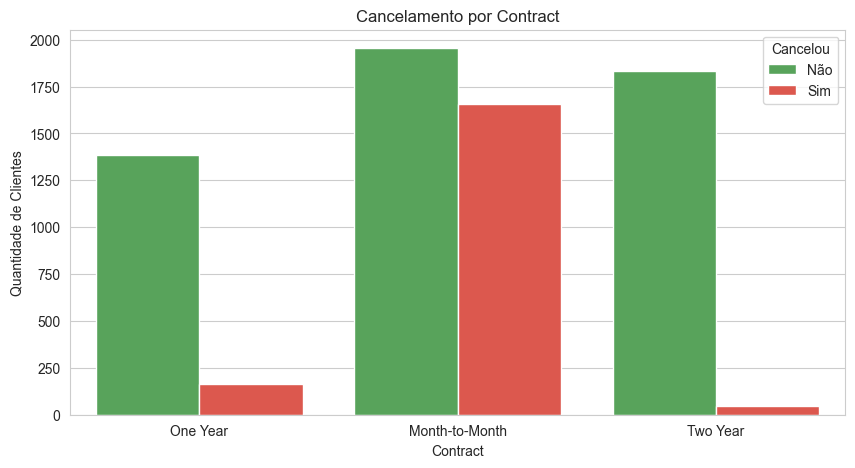

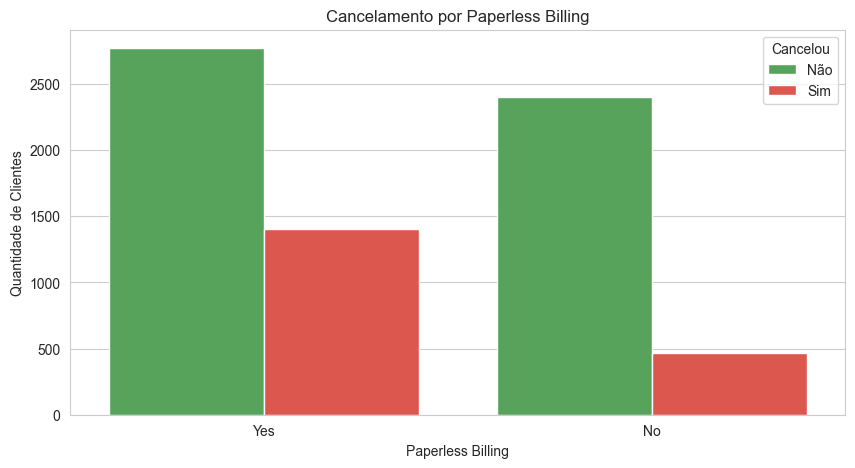

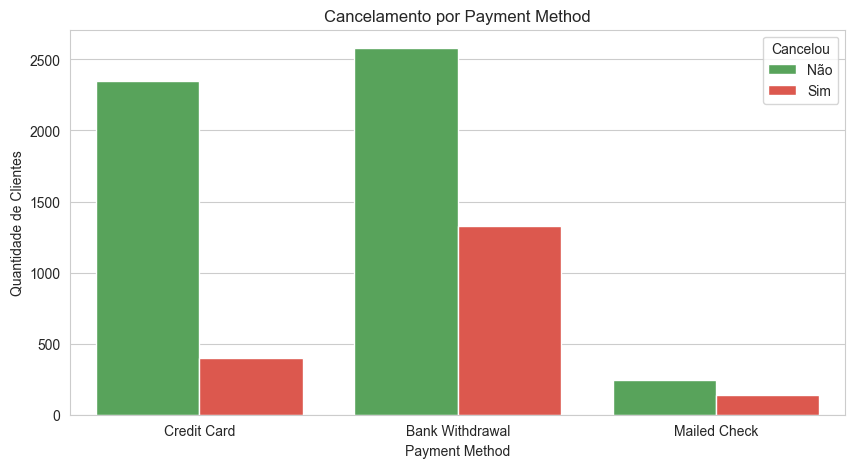

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Escolher o estilo e tamanho do gráfico
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Loop por cada coluna categórica, exceto 'Customer ID' e 'Customer Status'
for col in categorical_cols:
    if col not in ["Customer ID", "Customer Status", "Churn Category", "Churn Reason","City"]:
        plt.figure(figsize=(10,5))
        sns.countplot(x=col, hue="Churn_Binary", data=df, palette=["#4CAF50", "#F44336"])
        plt.title(f"Cancelamento por {col}")
        plt.xlabel(col)
        plt.ylabel("Quantidade de Clientes")
        plt.legend(title="Cancelou", labels=["Não", "Sim"])
        plt.show()


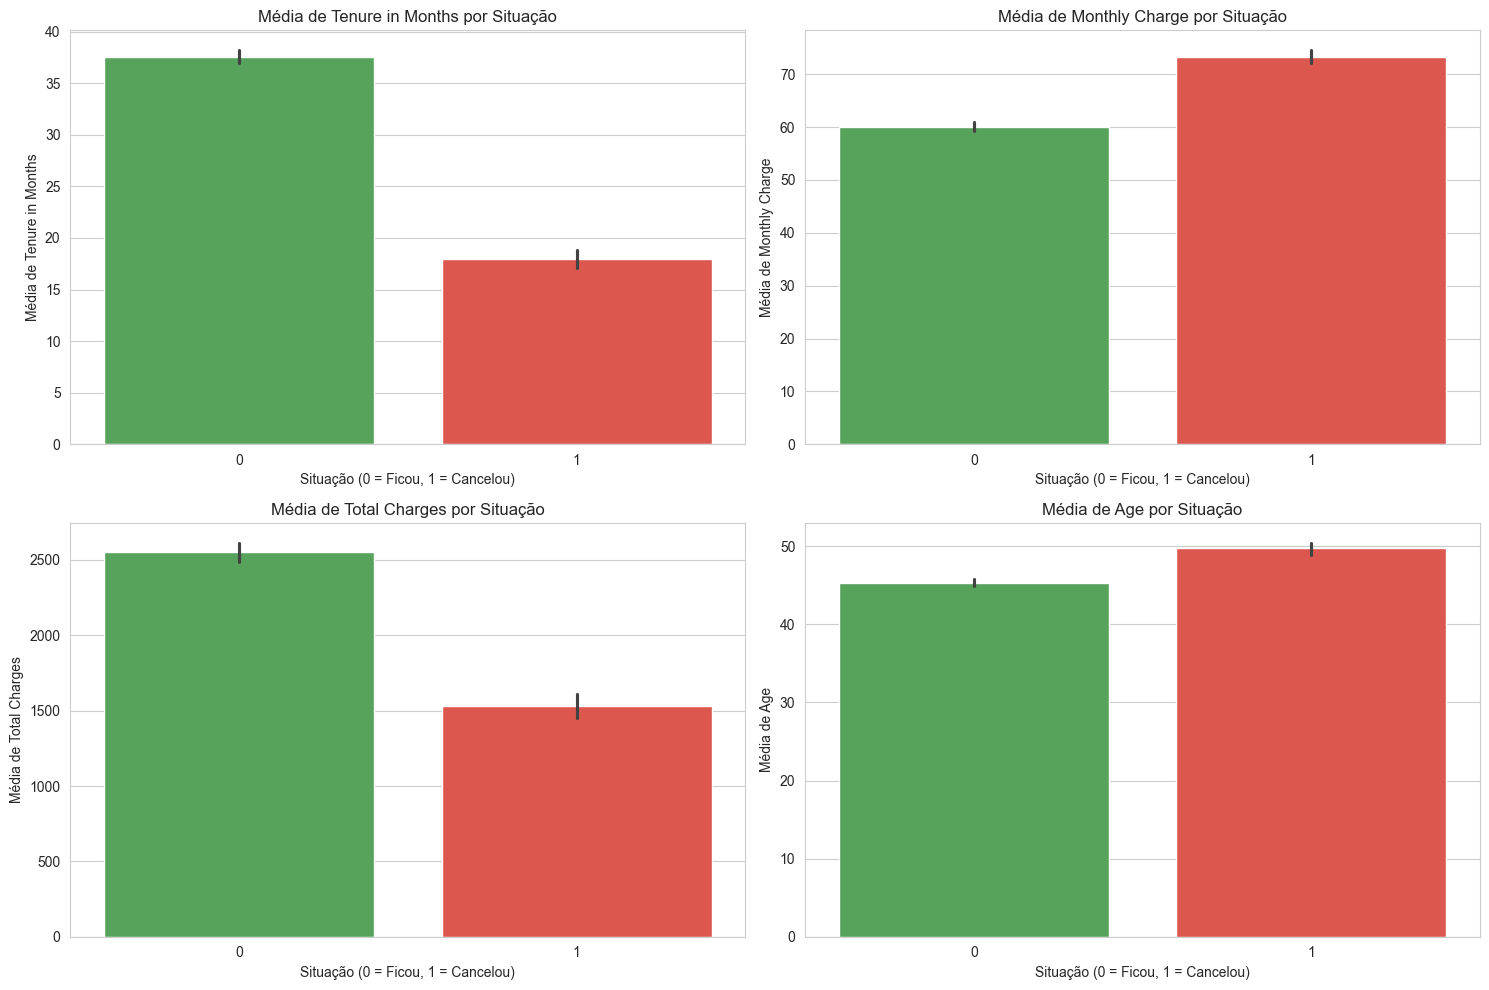

In [19]:
# ==========================
# ANÁLISE DE VARIÁVEIS NUMÉRICAS (SIMPLIFICADA)
# ==========================

# 1. Definimos as colunas numéricas
num_cols = ["Tenure in Months", "Monthly Charge", "Total Charges", "Age"]

# 2. Configura o tamanho da área de desenho
plt.figure(figsize=(15, 10))

# 3. Loop para criar os gráficos
for i, col in enumerate(num_cols):
    
    # Cria o sub-gráfico
    plt.subplot(2, 2, i+1)
    
    # Cria um Gráfico de Barras (Barplot)
    # Por padrão, o Seaborn calcula a MÉDIA e desenha a barra
    # O traço preto no topo da barra é o intervalo de confiança (pode ignorar por enquanto)
    sns.barplot(
        data=df, 
        x="Churn_Binary", 
        y=col, 
        hue="Churn_Binary",  # Define a cor baseado no Churn
        legend=False,        # Esconde a legenda duplicada
        palette=["#4CAF50", "#F44336"]
    )
    
    plt.title(f"Média de {col} por Situação")
    plt.xlabel("Situação (0 = Ficou, 1 = Cancelou)")
    plt.ylabel(f"Média de {col}")

# 4. Ajusta o espaçamento
plt.tight_layout()
plt.show()

In [20]:
# ==========================
# RENOMEANDO COLUNAS (TRADUÇÃO)
# ==========================

# Dicionário DE (Inglês) -> PARA (Português)
colunas_traduzidas = {
    # Cliente
    "Customer ID": "ID_Cliente",
    "Gender": "Genero",
    "Age": "Idade",
    "Married": "Casado",
    "Number of Dependents": "Numero_Dependentes",
    "City": "Cidade",
    "Zip Code": "CEP",
    "Number of Referrals": "Numero_Indicacoes",

    # Serviços
    "Tenure in Months": "Meses_de_Contrato",
    "Offer": "Oferta",
    "Phone Service": "Servico_Telefonico",
    "Multiple Lines": "Multiplas_Linhas",
    "Internet Service": "Servico_Internet",
    "Internet Type": "Tipo_Internet",
    "Online Security": "Seguranca_Online",
    "Online Backup": "Backup_Online",
    "Device Protection Plan": "Protecao_Dispositivo",
    "Premium Tech Support": "Suporte_Tecnico",
    "Streaming TV": "Streaming_TV",
    "Streaming Movies": "Streaming_Filmes",
    "Streaming Music": "Streaming_Musica",
    "Unlimited Data": "Dados_Ilimitados",

    # Contrato e Pagamento
    "Contract": "Tipo_Contrato",
    "Paperless Billing": "Fatura_Digital",
    "Payment Method": "Metodo_Pagamento",
    "Monthly Charge": "Mensalidade",
    "Total Charges": "Total_Cobrado",
    "Total Refunds": "Total_Reembolsos",
    "Total Revenue": "Receita_Total",

    # Status e Churn
    "Customer Status": "Status_Cliente",
    "Churn Category": "Categoria_Churn",
    "Churn Reason": "Motivo_Churn",
    
    # Nossa coluna criada
    "Churn_Binary": "Cancelou"  # Vamos simplificar para 'Cancelou' (0 ou 1)
}

# Aplicando a renomeação
df.rename(columns=colunas_traduzidas, inplace=True)

# Verificando se deu certo
print("Novas colunas:")
print(df.columns)
df.head()

Novas colunas:
Index(['ID_Cliente', 'Genero', 'Idade', 'Casado', 'Numero_Dependentes',
       'Cidade', 'CEP', 'Latitude', 'Longitude', 'Numero_Indicacoes',
       'Meses_de_Contrato', 'Oferta', 'Servico_Telefonico',
       'Avg Monthly Long Distance Charges', 'Multiplas_Linhas',
       'Servico_Internet', 'Tipo_Internet', 'Avg Monthly GB Download',
       'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo',
       'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes',
       'Streaming_Musica', 'Dados_Ilimitados', 'Tipo_Contrato',
       'Fatura_Digital', 'Metodo_Pagamento', 'Mensalidade', 'Total_Cobrado',
       'Total_Reembolsos', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Receita_Total', 'Status_Cliente',
       'Categoria_Churn', 'Motivo_Churn', 'Cancelou'],
      dtype='str')


,ID_Cliente,Genero,Idade,Casado,Numero_Dependentes,Cidade,CEP,Latitude,Longitude,Numero_Indicacoes,...,Mensalidade,Total_Cobrado,Total_Reembolsos,Total Extra Data Charges,Total Long Distance Charges,Receita_Total,Status_Cliente,Categoria_Churn,Motivo_Churn,Cancelou
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN,0
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN,0
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,1
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,1
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,1


In [21]:
# ==========================
# 5. TRATAMENTO DE DADOS - INSPEÇÃO
# ==========================

# 1. Verificar duplicatas
duplicates = df.duplicated().sum()
print(f"Linhas duplicadas: {duplicates}")

# 2. Verificar nulos
print("\nValores nulos por coluna:")
print(df.isnull().sum())

# 3. Verificar tipos (note que agora usamos 'Total_Cobrado')
print("\nTipos das colunas:")
print(df.dtypes)

Linhas duplicadas: 0

Valores nulos por coluna:
ID_Cliente                              0
Genero                                  0
Idade                                   0
Casado                                  0
Numero_Dependentes                      0
Cidade                                  0
CEP                                     0
Latitude                                0
Longitude                               0
Numero_Indicacoes                       0
Meses_de_Contrato                       0
Oferta                               3877
Servico_Telefonico                      0
Avg Monthly Long Distance Charges     682
Multiplas_Linhas                      682
Servico_Internet                        0
Tipo_Internet                        1526
Avg Monthly GB Download              1526
Seguranca_Online                     1526
Backup_Online                        1526
Protecao_Dispositivo                 1526
Suporte_Tecnico                      1526
Streaming_TV                

In [22]:
# ==========================
# 1. FINALIZANDO A TRADUÇÃO
# ==========================
# Ficaram algumas colunas em inglês, vamos ajustar agora
cols_extras = {
    "Avg Monthly Long Distance Charges": "Media_Cobranca_Distancia",
    "Avg Monthly GB Download": "Media_GB_Download",
    "Total Extra Data Charges": "Total_Cobranca_Dados_Extra",
    "Total Long Distance Charges": "Total_Cobranca_Distancia"
}
df.rename(columns=cols_extras, inplace=True)

# ==========================
# 2. PREENCHIMENTO DE NULOS (IMPUTAÇÃO)
# ==========================

# A) Tratando quem não tem Internet (1526 casos)
# Colunas de texto -> Colocamos "Sem Internet"
cols_sem_internet = [
    "Tipo_Internet", "Seguranca_Online", "Backup_Online", 
    "Protecao_Dispositivo", "Suporte_Tecnico", "Streaming_TV", 
    "Streaming_Filmes", "Streaming_Musica", "Dados_Ilimitados"
]
for col in cols_sem_internet:
    df[col] = df[col].fillna("Sem Internet")

# Coluna numérica -> Colocamos 0
df["Media_GB_Download"] = df["Media_GB_Download"].fillna(0)


# B) Tratando quem não tem Telefone (682 casos)
# Texto -> "Sem Telefone"
df["Multiplas_Linhas"] = df["Multiplas_Linhas"].fillna("Sem Telefone")

# Numérico -> 0
df["Media_Cobranca_Distancia"] = df["Media_Cobranca_Distancia"].fillna(0)


# C) Tratando Ofertas (3877 casos)
# Se está vazio, o cliente não aceitou nenhuma oferta
df["Oferta"] = df["Oferta"].fillna("Sem Oferta")


# D) Tratando Churn (5174 casos)
# Se o cliente ainda está ativo, não tem categoria nem motivo de saída
df["Categoria_Churn"] = df["Categoria_Churn"].fillna("Nao Aplicavel")
df["Motivo_Churn"] = df["Motivo_Churn"].fillna("Nao Aplicavel")


# ==========================
# 3. VERIFICAÇÃO FINAL
# ==========================
print("Quantidade de nulos restantes:", df.isnull().sum().sum())
print("\nVerificando se sobrou alguma coluna em inglês:")
print(df.columns)

Quantidade de nulos restantes: 0

Verificando se sobrou alguma coluna em inglês:
Index(['ID_Cliente', 'Genero', 'Idade', 'Casado', 'Numero_Dependentes',
       'Cidade', 'CEP', 'Latitude', 'Longitude', 'Numero_Indicacoes',
       'Meses_de_Contrato', 'Oferta', 'Servico_Telefonico',
       'Media_Cobranca_Distancia', 'Multiplas_Linhas', 'Servico_Internet',
       'Tipo_Internet', 'Media_GB_Download', 'Seguranca_Online',
       'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico',
       'Streaming_TV', 'Streaming_Filmes', 'Streaming_Musica',
       'Dados_Ilimitados', 'Tipo_Contrato', 'Fatura_Digital',
       'Metodo_Pagamento', 'Mensalidade', 'Total_Cobrado', 'Total_Reembolsos',
       'Total_Cobranca_Dados_Extra', 'Total_Cobranca_Distancia',
       'Receita_Total', 'Status_Cliente', 'Categoria_Churn', 'Motivo_Churn',
       'Cancelou'],
      dtype='str')


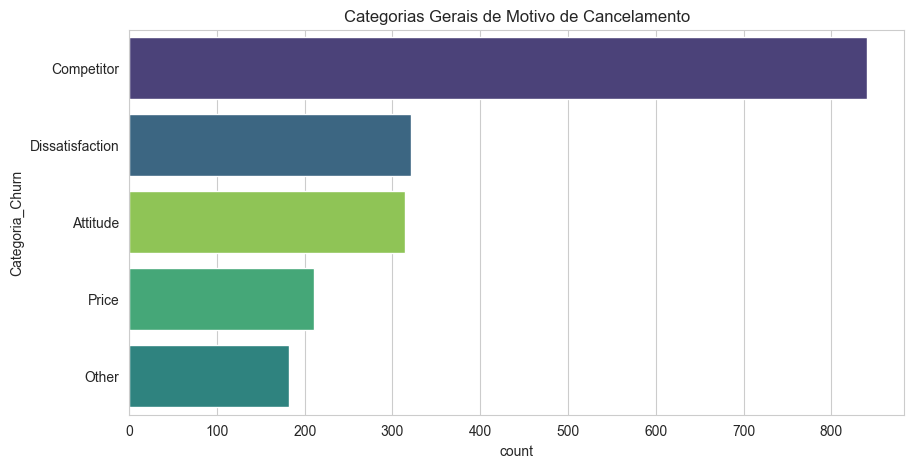

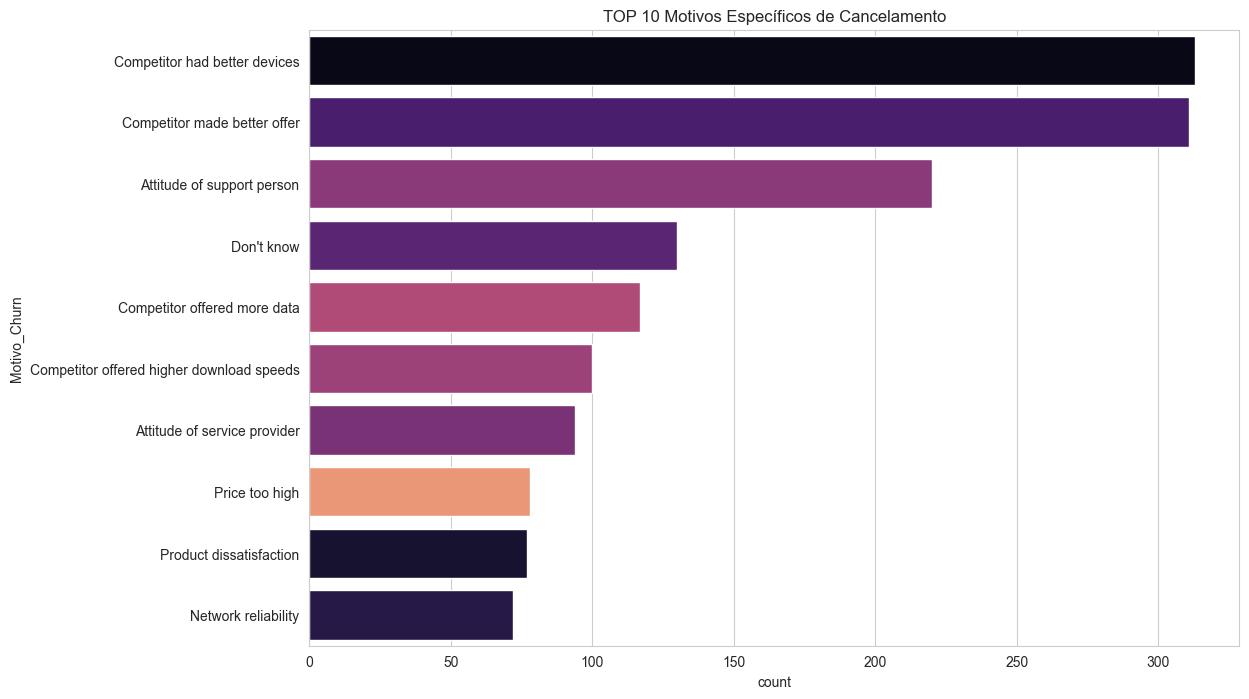

In [ ]:
# ==========================
# ANÁLISE PROFUNDA DOS MOTIVOS DE CANCELAMENTO
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar apenas quem cancelou (Cancelou == 1)
# Pois não faz sentido analisar motivo de quem NÃO saiu
df_churn = df[df["Cancelou"] == 1]

# 1. Gráfico das Grandes Categorias (Visão Geral)
plt.figure(figsize=(10, 5))
sns.countplot(
    y="Categoria_Churn", 
    data=df_churn, 
    order=df_churn["Categoria_Churn"].value_counts().index, 
    hue="Categoria_Churn",  
    palette="viridis",
    legend=False            # Remove legenda duplicada
)
plt.title("Categorias Gerais de Motivo de Cancelamento")
plt.show()

# 2. Gráfico dos Motivos Específicos (Top 10 Detalhes)
plt.figure(figsize=(12, 8))
top_motivos = df_churn["Motivo_Churn"].value_counts().head(10).index

sns.countplot(
    y="Motivo_Churn", 
    data=df_churn, 
    order=top_motivos, 
    hue="Motivo_Churn",     
    palette="magma",
    legend=False            # Remove legenda duplicada
)
plt.title("TOP 10 Motivos Específicos de Cancelamento")
plt.tight_layout()
plt.savefig("grafico_top10_motivos.png", dpi=300, bbox_inches="tight")
plt.show()

Top 10 Cidades com maior taxa de cancelamento:
               count      mean
Cidade                        
San Diego        285  0.649123
Fallbrook         43  0.604651
Temecula          38  0.578947
Glendale          40  0.325000
Escondido         51  0.313725
San Francisco    104  0.298077
Berkeley          32  0.281250
Stockton          44  0.272727
Los Angeles      293  0.266212
San Jose         112  0.258929


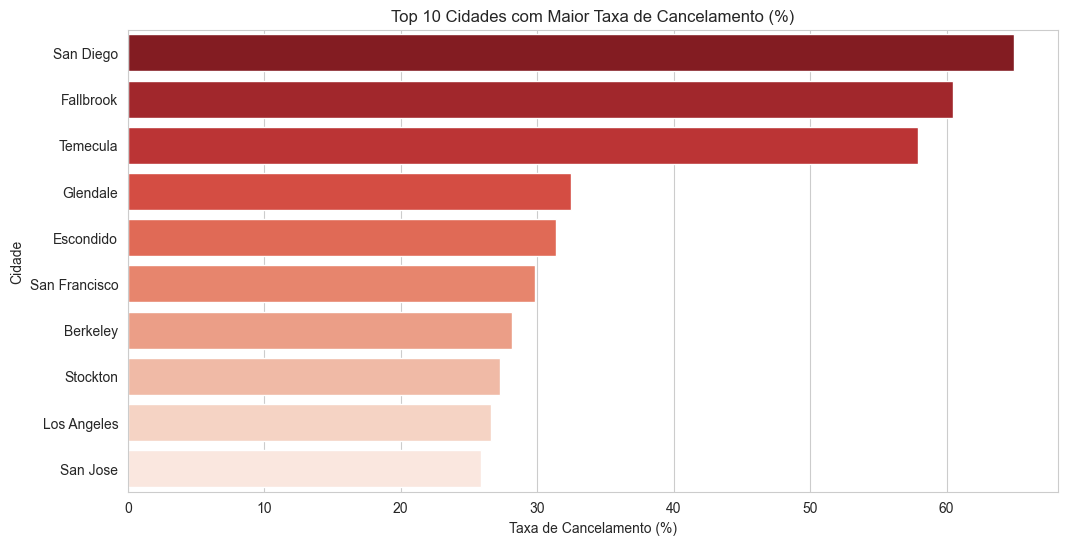

In [24]:
# ==========================
# ANÁLISE POR CIDADE 
# ==========================

# 1. Preparar os dados
# Agrupa por cidade e calcula:
# 'count': quantos clientes tem lá
# 'mean': qual a média de cancelamento (0 a 1, ou seja, porcentagem)
cidades = df.groupby("Cidade")["Cancelou"].agg(["count", "mean"])

# 2. Filtrar cidades insignificantes
# Só olhamos cidades com mais de 30 clientes para evitar distorções
# (Ex: uma cidade com 1 cliente que cancelou daria 100% de churn, o que é enganoso)
cidades_filtradas = cidades[cidades["count"] > 30]

# 3. Pegar as 10 piores (maiores médias de cancelamento)
top_cidades = cidades_filtradas.sort_values(by="mean", ascending=False).head(10)

# Exibir a tabela com os números exatos
print("Top 10 Cidades com maior taxa de cancelamento:")
print(top_cidades)

# 4. Gerar o Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(
    y=top_cidades.index, 
    x=top_cidades["mean"] * 100, # Multiplica por 100 para virar %
    hue=top_cidades.index,       # CORREÇÃO: Define a cor pela cidade
    palette="Reds_r",            # Cor vermelha (alerta)
    legend=False                 # Remove legenda duplicada
)

plt.title("Top 10 Cidades com Maior Taxa de Cancelamento (%)")
plt.xlabel("Taxa de Cancelamento (%)")
plt.ylabel("Cidade")
plt.show()

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados 
try:
    df = pd.read_csv("telecom_customer_churn.csv") 
except:
    df = pd.read_csv("../data/telecom_customer_churn.csv") #

# 2. Criar a coluna binária de Churn (0 e 1) ANTES de traduzir
df["Churn_Binary"] = df["Customer Status"].map({"Stayed": 0, "Joined": 0, "Churned": 1})

# 3. Traduzir Colunas (Dicionário Completo)
colunas_traduzidas = {
    "Customer ID": "ID_Cliente",
    "Gender": "Genero",
    "Age": "Idade",
    "Married": "Casado",
    "Number of Dependents": "Numero_Dependentes",
    "City": "Cidade",
    "Zip Code": "CEP",
    "Number of Referrals": "Numero_Indicacoes",
    "Tenure in Months": "Meses_de_Contrato",
    "Offer": "Oferta",
    "Phone Service": "Servico_Telefonico",
    "Multiple Lines": "Multiplas_Linhas",
    "Internet Service": "Servico_Internet",
    "Internet Type": "Tipo_Internet",
    "Online Security": "Seguranca_Online",
    "Online Backup": "Backup_Online",
    "Device Protection Plan": "Protecao_Dispositivo",
    "Premium Tech Support": "Suporte_Tecnico",
    "Streaming TV": "Streaming_TV",
    "Streaming Movies": "Streaming_Filmes",
    "Streaming Music": "Streaming_Musica",
    "Unlimited Data": "Dados_Ilimitados",
    "Contract": "Tipo_Contrato",
    "Paperless Billing": "Fatura_Digital",
    "Payment Method": "Metodo_Pagamento",
    "Monthly Charge": "Mensalidade",
    "Total Charges": "Total_Cobrado",
    "Total Refunds": "Total_Reembolsos",
    "Total Revenue": "Receita_Total",
    "Customer Status": "Status_Cliente",
    "Churn Category": "Categoria_Churn",
    "Churn Reason": "Motivo_Churn",
    "Churn_Binary": "Cancelou",
    "Avg Monthly Long Distance Charges": "Media_Cobranca_Distancia",
    "Avg Monthly GB Download": "Media_GB_Download",
    "Total Extra Data Charges": "Total_Cobranca_Dados_Extra",
    "Total Long Distance Charges": "Total_Cobranca_Distancia"
}
df.rename(columns=colunas_traduzidas, inplace=True)

# 4. Limpeza de Nulos (Imputação)
# A) Sem Internet
cols_sem_internet = ["Tipo_Internet", "Seguranca_Online", "Backup_Online", 
                     "Protecao_Dispositivo", "Suporte_Tecnico", "Streaming_TV", 
                     "Streaming_Filmes", "Streaming_Musica", "Dados_Ilimitados"]
for col in cols_sem_internet:
    df[col] = df[col].fillna("Sem Internet")
    
df["Media_GB_Download"] = df["Media_GB_Download"].fillna(0)

# B) Sem Telefone
df["Multiplas_Linhas"] = df["Multiplas_Linhas"].fillna("Sem Telefone")
df["Media_Cobranca_Distancia"] = df["Media_Cobranca_Distancia"].fillna(0)

# C) Outros
df["Oferta"] = df["Oferta"].fillna("Sem Oferta")
df["Categoria_Churn"] = df["Categoria_Churn"].fillna("Nao Aplicavel")
df["Motivo_Churn"] = df["Motivo_Churn"].fillna("Nao Aplicavel")

print("✅ Dados recuperados com sucesso!")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()

✅ Dados recuperados com sucesso!
Linhas: 7043 | Colunas: 39


,ID_Cliente,Genero,Idade,Casado,Numero_Dependentes,Cidade,CEP,Latitude,Longitude,Numero_Indicacoes,...,Mensalidade,Total_Cobrado,Total_Reembolsos,Total_Cobranca_Dados_Extra,Total_Cobranca_Distancia,Receita_Total,Status_Cliente,Categoria_Churn,Motivo_Churn,Cancelou
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,65.6,593.30,0.00,0,381.51,974.81,Stayed,Nao Aplicavel,Nao Aplicavel,0
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,-4.0,542.40,38.33,10,96.21,610.28,Stayed,Nao Aplicavel,Nao Aplicavel,0
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,1
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,1
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,1


In [26]:
# ==========================
# 6. ANÁLISE FINANCEIRA (DINHEIRO NA MESA)
# ==========================

# Filtra apenas quem cancelou
df_churn = df[df["Cancelou"] == 1]

# Agrupando pelo motivo e somamos a mensalidade
perda_por_motivo = df_churn.groupby("Motivo_Churn")["Mensalidade"].sum().sort_values(ascending=False)

# Transformando em um DataFrame 
tabela_financeira = perda_por_motivo.reset_index()
tabela_financeira.columns = ["Motivo do Cancelamento", "Prejuízo Mensal ($)"]

# Mostra os 10 maiores prejuízos
print("💰 TOP 10 Motivos que mais dão prejuízo financeiro:")
display(tabela_financeira.head(10))

# Vamos calcular o total
total_perda = df_churn["Mensalidade"].sum()
print(f"\n💸 Prejuízo Mensal Total Recorrente: ${total_perda:,.2f}")

💰 TOP 10 Motivos que mais dão prejuízo financeiro:


,Motivo do Cancelamento,Prejuízo Mensal ($)
0,Competitor had better devices,23891.50
1,Competitor made better offer,22903.35
2,Attitude of support person,14934.70
3,Don't know,9646.60
4,Competitor offered more data,9371.40
5,Competitor offered higher download speeds,7576.60
6,Attitude of service provider,6959.90
7,Price too high,5916.95
8,Product dissatisfaction,5877.00
9,Network reliability,5338.70



💸 Prejuízo Mensal Total Recorrente: $137,086.65


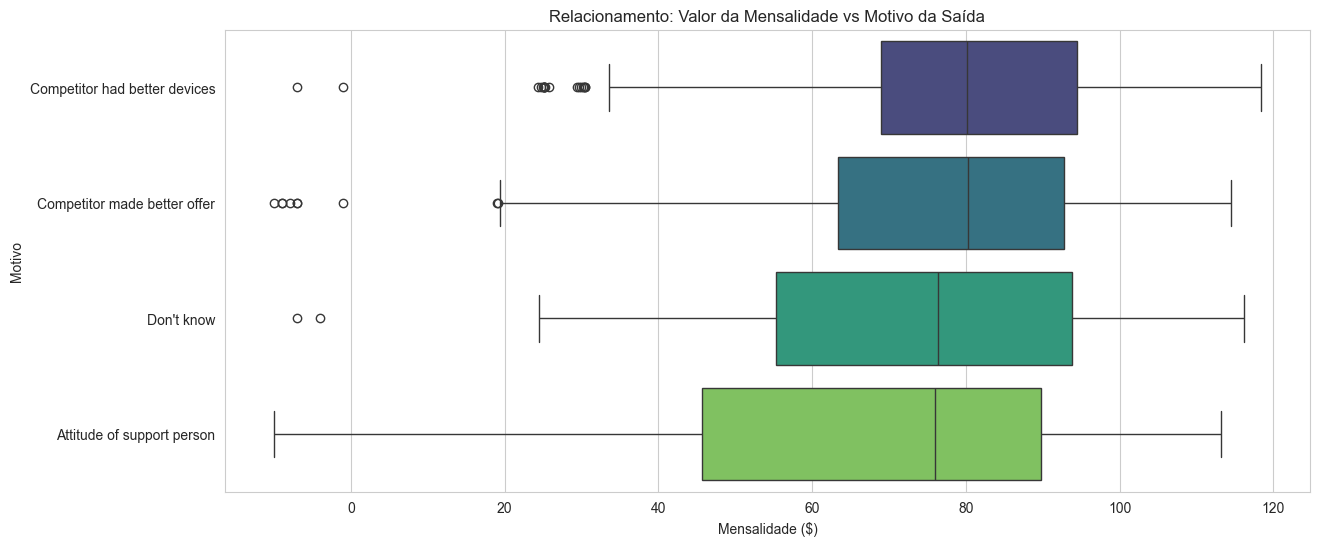

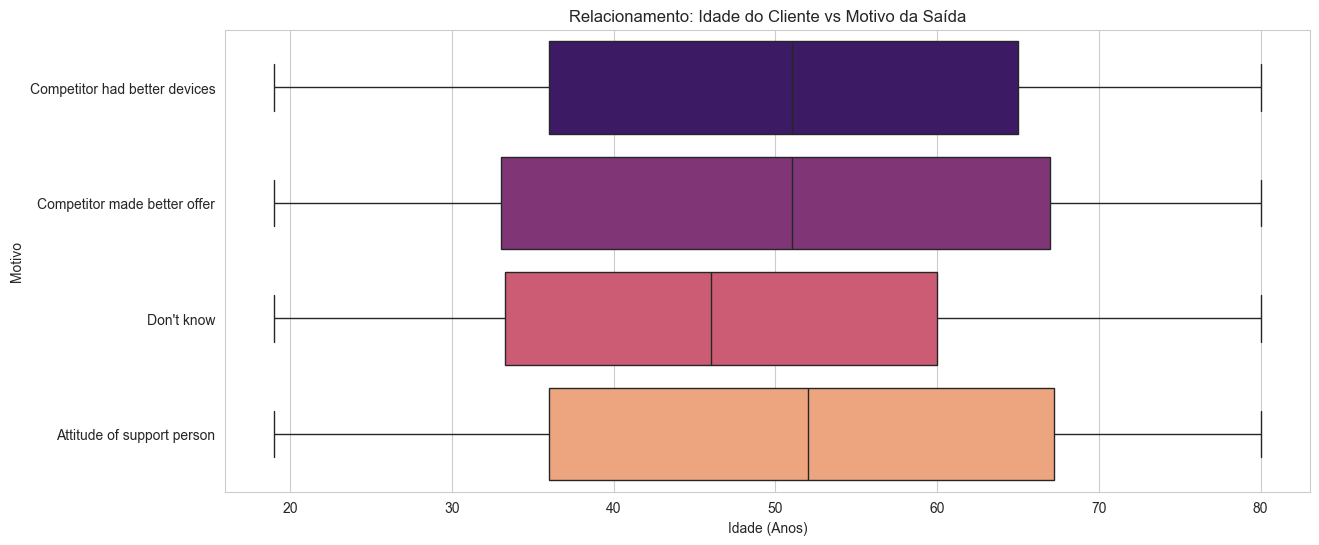

In [27]:
# ==========================
# 7. PERFIL DO CLIENTE (QUEM SÃO ELES?)
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# Focar apenas nos 4 principais motivos financeiros 
top_4_motivos = [
    "Competitor had better devices",
    "Competitor made better offer",
    "Attitude of support person",
    "Don't know"
]

# Filtrar o dataset para pegar só esses motivos
df_analise = df[df["Motivo_Churn"].isin(top_4_motivos)]

# Configurar o tamanho da imagem
plt.figure(figsize=(14, 6))

# GRÁFICO 1: Quem paga mais caro sai por qual motivo?
# Boxplot cruza uma Categoria (Eixo X) com um Valor (Eixo Y)
sns.boxplot(
    data=df_analise,
    x="Mensalidade",
    y="Motivo_Churn",
    palette="viridis",
    hue="Motivo_Churn",  
    legend=False
)

plt.title("Relacionamento: Valor da Mensalidade vs Motivo da Saída")
plt.xlabel("Mensalidade ($)")
plt.ylabel("Motivo")
plt.show()

# GRÁFICO 2: Idade influencia na tolerância ao suporte ruim?
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_analise,
    x="Idade",
    y="Motivo_Churn",
    palette="magma",
    hue="Motivo_Churn",
    legend=False
)

plt.title("Relacionamento: Idade do Cliente vs Motivo da Saída")
plt.xlabel("Idade (Anos)")
plt.ylabel("Motivo")
plt.show()

In [28]:
# ==========================
# 7. EXPORTAÇÃO DOS DADOS
# ==========================

# Salva o arquivo limpo em CSV
df.to_csv("telecom_churn_analisado.csv", index=False)

print("✅ Arquivo 'telecom_churn_analisado.csv' salvo com sucesso!")


✅ Arquivo 'telecom_churn_analisado.csv' salvo com sucesso!
